# ABC CaDSD, 9 Cases, Self-Contained

This notebook is self-contained: it does **not** import the terminal runner.

The simulation follows the 9-case structure from the plot:

- columns: target raw correlation $r(y,z) \in \{0, 0.80, 0.90\}$
- rows: target inclusion-probability relationship $r(y,\pi) \in \{0, 0.80, 0.90\}$
- $r(y/\pi,z/\pi)$ is **reported as an outcome**, not imposed.

Important: Vincent's monotone condition is checked explicitly. It is not silently assumed.

## 1. Imports and Settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Union
from IPython.display import display

N_UNITS = 50
N_SAMPLE = 7
BASE_SEED = 20260706

Z_CORRELATIONS = [0.00, 0.80, 0.90]
PI_CASES = ["equal", "pi80", "pi90"]

MAX_ITERATIONS = 100
CHECKPOINT_INTERVAL = 100
COLONY_SIZE = 8
LIMIT = 5
ONLOOKER_FACTOR = 0.5
VALIDATION_MODE = "strict"

np.set_printoptions(precision=4, suppress=True)

## 2. Mathematical Functions

In [2]:
def Ppi(Pi: Union[np.ndarray, list]) -> np.ndarray:
    Pi = np.asarray(Pi, dtype=float).ravel()
    N = Pi.size
    if N < 2:
        raise ValueError("length(Pi) must be > 1")
    if np.any(Pi <= 0) or np.any(Pi >= 1):
        raise ValueError("Pi must satisfy 0 < p < 1")
    n_int = int(round(Pi.sum(), 9))
    if abs(Pi.sum() - n_int) > 1e-8:
        raise ValueError("sum(Pi) must be an integer")

    s_vals = np.zeros(N)
    c_vals = np.zeros(N)
    alpha = np.zeros(N)
    kr = [None] * n_int

    cum_sum = 0.0
    r = 1
    r_prev = 0
    for k in range(N):
        prev_sum = cum_sum
        cum_sum += Pi[k]
        if cum_sum >= r:
            if r <= n_int:
                alpha[k] = r - prev_sum
                kr[r - 1] = k
                s_vals[k] = np.round(np.sqrt((1.0 - Pi[k]) / (1.0 - alpha[k])), 8)
                r_prev = r
                r += 1
        else:
            denom = r_prev + 1 - prev_sum
            s_vals[k] = np.round(np.sqrt(Pi[k] / denom), 15)
        c_vals[k] = np.sqrt(1.0 - s_vals[k] ** 2)

    if any(x is None for x in kr):
        kr[-1] = N - 1
    last_index = kr[-1]
    kr = [last_index if x is None else x for x in kr]

    V = np.zeros((N, n_int))
    V[0, 0] = 1.0
    for r_idx in range(1, n_int):
        kpos = kr[r_idx - 1]
        V[kpos + 1, r_idx] = 1.0

    for k in range(N - 1):
        L = V[k, :].copy()
        M = V[k + 1, :].copy()
        V[k, :] = s_vals[k] * L - c_vals[k] * M
        V[k + 1, :] = c_vals[k] * L + s_vals[k] * M
    return V


def inclusionprobabilities(p, n):
    p = np.asarray(p, dtype=float)
    N = p.size
    if n <= 0 or n > N:
        raise ValueError("n must be in 1..N")
    pik = np.zeros(N)
    fixed = np.zeros(N, dtype=bool)
    n_rem = float(n)
    p_work = p.copy()
    while True:
        idx = ~fixed
        if not np.any(idx):
            break
        p_sub = p_work[idx]
        if p_sub.sum() <= 0 and n_rem > 1e-12:
            raise RuntimeError("Cannot construct inclusion probabilities")
        temp = n_rem * p_sub / p_sub.sum()
        over = temp >= (1.0 - 1e-12)
        if not np.any(over):
            pik[idx] = temp
            break
        idx_global = np.where(idx)[0]
        over_global = idx_global[over]
        pik[over_global] = 1.0
        fixed[over_global] = True
        n_rem -= over.sum()
        p_work[over_global] = 0.0
        if n_rem <= 1e-12:
            break
    return pik


def spec(omega: np.ndarray, M: int, pi: Union[np.ndarray, list], spectre=100) -> np.ndarray:
    pi = np.asarray(pi, dtype=float).ravel()
    N = pi.size
    omega = np.asarray(omega, dtype=float)
    if omega.shape != (M, N):
        raise ValueError("omega must have shape (M, N)")
    mat_spectre = np.zeros((M, N), dtype=float)
    pi_down = np.sort(pi)[::-1]
    pi_prefix = np.concatenate(([0.0], np.cumsum(pi_down)))
    mu = float(pi.sum())

    if np.isscalar(spectre) and spectre == 100:
        spectre_vec = np.zeros(M)
        cumsum_1 = 0.0
        lam = 0.0
        for j in range(M - 1):
            jR = j + 1
            A = max(lam, mu - cumsum_1 - (M - jR))
            B = 1.0
            for iR in range(1, M - jR + 1):
                t_idx = M - jR - iR + 1
                B = min(B, (mu - cumsum_1 - pi_prefix[t_idx]) / iR)
            B = min(B, (mu - cumsum_1) / (M - jR + 1))
            spectre_vec[j] = A + omega[j, N - 1] * (B - A)
            lam = spectre_vec[j]
            cumsum_1 += spectre_vec[j]
        spectre_vec[M - 1] = mu - spectre_vec[: M - 1].sum()
    else:
        spectre_vec = np.asarray(spectre, dtype=float).ravel()
        if spectre_vec.size != M:
            raise ValueError("spectre must have length M")

    mat_spectre[:, N - 1] = spectre_vec
    for kR in range(N - 1, 0, -1):
        startR = max(1, M - kR + 1)
        lambda1 = mat_spectre[:, kR].copy()
        prefix_l1 = np.concatenate(([0.0], np.cumsum(lambda1)))
        cum_l2_before_j = 0.0
        for jR in range(startR, M + 1):
            lam_prev = lambda1[jR - 2] if jR >= 2 else 0.0
            sum_l1 = prefix_l1[jR]
            A = max(0.0, lam_prev, sum_l1 - cum_l2_before_j - pi_down[kR])
            B_inner = float("inf")
            for iR in range(jR, M + 1):
                start_idx0 = M - iR
                prem = pi_prefix[kR] - pi_prefix[start_idx0] if start_idx0 < kR else 0.0
                deux = prefix_l1[iR - 1] - prefix_l1[jR - 1] if jR <= (iR - 1) else 0.0
                B_inner = min(B_inner, prem - deux - cum_l2_before_j)
            B = min(lambda1[jR - 1], B_inner)
            new_val = A + omega[jR - 1, kR - 1] * (B - A)
            mat_spectre[jR - 1, kR - 1] = new_val
            cum_l2_before_j += new_val
    return mat_spectre


def CaDsd(pi, M=None, omega=None, rho=None, spectre=100, U=None, option=True):
    pi = np.asarray(pi, dtype=float).ravel()
    N = pi.size
    if M is None:
        M = int(round(pi.sum(), 7))
    M = int(M)
    omega = 0.5 * np.ones((M, N)) if omega is None else np.asarray(omega, dtype=float)
    rho = 0.5 * np.ones((M, N - 1)) if rho is None else np.asarray(rho, dtype=float)
    if omega.shape != (M, N):
        raise ValueError("omega must have shape (M, N)")
    if rho.shape != (M, N - 1):
        raise ValueError("rho must have shape (M, N-1)")

    rho_angles = np.round(rho * 2 * np.pi, 7)
    mat_spectre = np.round(spec(omega, M, pi, spectre), 7)
    pi_down = np.sort(pi)[::-1]
    U_work = np.eye(M, dtype=complex) if U is None else np.asarray(U, dtype=complex).copy()
    phi = np.zeros((M, N), dtype=complex)
    phi[:, 0] = np.round(np.sqrt(pi_down[0]) * U_work[:, 0], 7)
    ens = np.arange(1, M + 1, dtype=int)
    eye_index = np.arange(M)

    for kR in range(2, N + 1):
        phases = np.exp(1j * rho_angles[:, kR - 2])
        lambda1 = mat_spectre[:, kR - 1].copy()
        lambda2 = mat_spectre[:, kR - 2].copy()
        E1 = ens.tolist()
        E2 = ens.tolist()
        for jR in ens:
            if not E1:
                break
            val = lambda2[jR - 1]
            matches = np.where(lambda1[np.array(E1) - 1] == val)[0]
            if matches.size > 0:
                E2 = [x for x in E2 if x != jR]
                del E1[matches[0]]
        E1_arr = np.array(E1, dtype=int)
        E2_arr = np.array(E2, dtype=int)
        E1_rev = M + 1 - E1_arr
        E2_rev = M + 1 - E2_arr
        r = len(E1_rev)
        if r == 0:
            continue
        if r != M:
            mask1 = np.ones(M, dtype=bool)
            mask2 = np.ones(M, dtype=bool)
            mask1[E1_rev - 1] = False
            mask2[E2_rev - 1] = False
            perm1 = np.concatenate([np.sort(E1_rev), ens[mask1]]) - 1
            perm2 = np.concatenate([np.sort(E2_rev), ens[mask2]]) - 1
        else:
            perm1 = eye_index
            perm2 = eye_index
        R = np.column_stack([lambda2[E2_arr - 1], lambda1[E1_arr - 1]]).astype(complex)[::-1, :]
        v = np.zeros(r, dtype=complex)
        w = np.zeros(r, dtype=complex)
        for i in range(r):
            v1 = R[i, 0] - R[:, 1]
            v2 = R[i, 0] - R[:, 0]
            v2[i] = 1.0 + 0j
            v[i] = np.round(np.sqrt(-np.prod(v1[np.argsort(np.abs(v1))] / v2[np.argsort(np.abs(v1))])), 7)
            w1 = R[i, 1] - R[:, 0]
            w2 = R[i, 1] - R[:, 1]
            w2[i] = 1.0 + 0j
            w[i] = np.round(np.sqrt(np.prod(w1[np.argsort(np.abs(w1))] / w2[np.argsort(np.abs(w1))])), 7)
        W = (v[:, None] * w[None, :]) / (R[:, 1][None, :] - R[:, 0][:, None])
        UV = U_work * phases[None, :]
        UV_sigma2 = UV[:, perm2]
        phi[:, kR - 1] = UV_sigma2[:, :r] @ v
        U_block = UV_sigma2.copy()
        U_block[:, :r] = UV_sigma2[:, :r] @ W
        U_new = np.empty_like(U_block)
        U_new[:, perm1] = U_block
        U_work = U_new
    K = np.round(phi.conj().T @ phi, 7)
    return {"K": K, "spectrum": mat_spectre}

## 3. Variance, Validation, Population Generation

In [3]:
def standardize(x):
    x = np.asarray(x, dtype=float)
    sd = x.std(ddof=1)
    if sd == 0:
        return np.zeros_like(x)
    return (x - x.mean()) / sd


def correlated_with_target(target_std, corr, rng):
    noise = rng.normal(size=len(target_std))
    noise = noise - noise.mean()
    noise = noise - np.dot(noise, target_std) / np.dot(target_std, target_std) * target_std
    noise = standardize(noise)
    return corr * target_std + np.sqrt(max(0.0, 1.0 - corr**2)) * noise


def srs_variance(values, n_sample=N_SAMPLE):
    values = np.asarray(values, dtype=float)
    N = len(values)
    return N**2 * (1.0 - n_sample / N) * np.var(values, ddof=1) / n_sample


def ht_variance(K, pi, values):
    K = np.asarray(K, dtype=np.complex128)
    diag_K = np.real(np.diag(K))
    A = -np.abs(K) ** 2
    np.fill_diagonal(A, diag_K * (1.0 - diag_K))
    values_over_pi = values / pi
    return float(np.real(values_over_pi @ (A @ values_over_pi)))


def kernel_is_valid(K, pi, n_sample=N_SAMPLE, tol=1e-3, strict=True):
    K = np.asarray(K, dtype=np.complex128)
    if not np.all(np.isfinite(K)):
        return False
    if not np.allclose(K, K.conj().T, atol=tol):
        return False
    if not np.allclose(np.real(np.diag(K)), pi, atol=tol):
        return False
    if strict:
        vals = np.linalg.eigvalsh(K)
        if np.any(vals < -tol) or np.any(vals > 1.0 + tol):
            return False
        if not np.isclose(vals.sum(), n_sample, atol=tol):
            return False
    return True


def corr_suffix(corr):
    return f"{int(round(corr * 100)):02d}"


def make_size_for_pi(x, strength):
    return np.exp(strength * standardize(x))


def pi_for_target_corr(y, target_corr, rng):
    if target_corr == 0:
        return np.full(len(y), N_SAMPLE / len(y))
    y_std = standardize(y)
    size_base = correlated_with_target(y_std, target_corr, rng)
    strengths = np.linspace(0.05, 4.0, 300)
    best = None
    for strength in strengths:
        pi = inclusionprobabilities(make_size_for_pi(size_base, strength), N_SAMPLE)
        err = abs(np.corrcoef(y, pi)[0, 1] - target_corr)
        if best is None or err < best[0]:
            best = (err, pi, strength)
    return best[1]


def make_population(seed=BASE_SEED):
    rng = np.random.default_rng(seed)
    y = 90.0 + 12.0 * rng.normal(size=N_UNITS)
    y_std = standardize(y)
    data = {"unit": np.arange(N_UNITS), "y": y}
    z_names = []
    for corr in Z_CORRELATIONS:
        name = f"z{corr_suffix(corr)}"
        data[name] = correlated_with_target(y_std, corr, rng)
        z_names.append(name)
    df = pd.DataFrame(data)
    pi_dict = {
        "equal": np.full(N_UNITS, N_SAMPLE / N_UNITS),
        "pi80": pi_for_target_corr(y, 0.80, rng),
        "pi90": pi_for_target_corr(y, 0.90, rng),
    }
    return df, z_names, pi_dict


df_pop, z_names, pi_dict = make_population()
print("z variables:", z_names)
print("pi cases:", list(pi_dict.keys()))

z variables: ['z00', 'z80', 'z90']
pi cases: ['equal', 'pi80', 'pi90']


## 4. Plot the Problem: Raw Correlation vs HT-Scaled Correlation

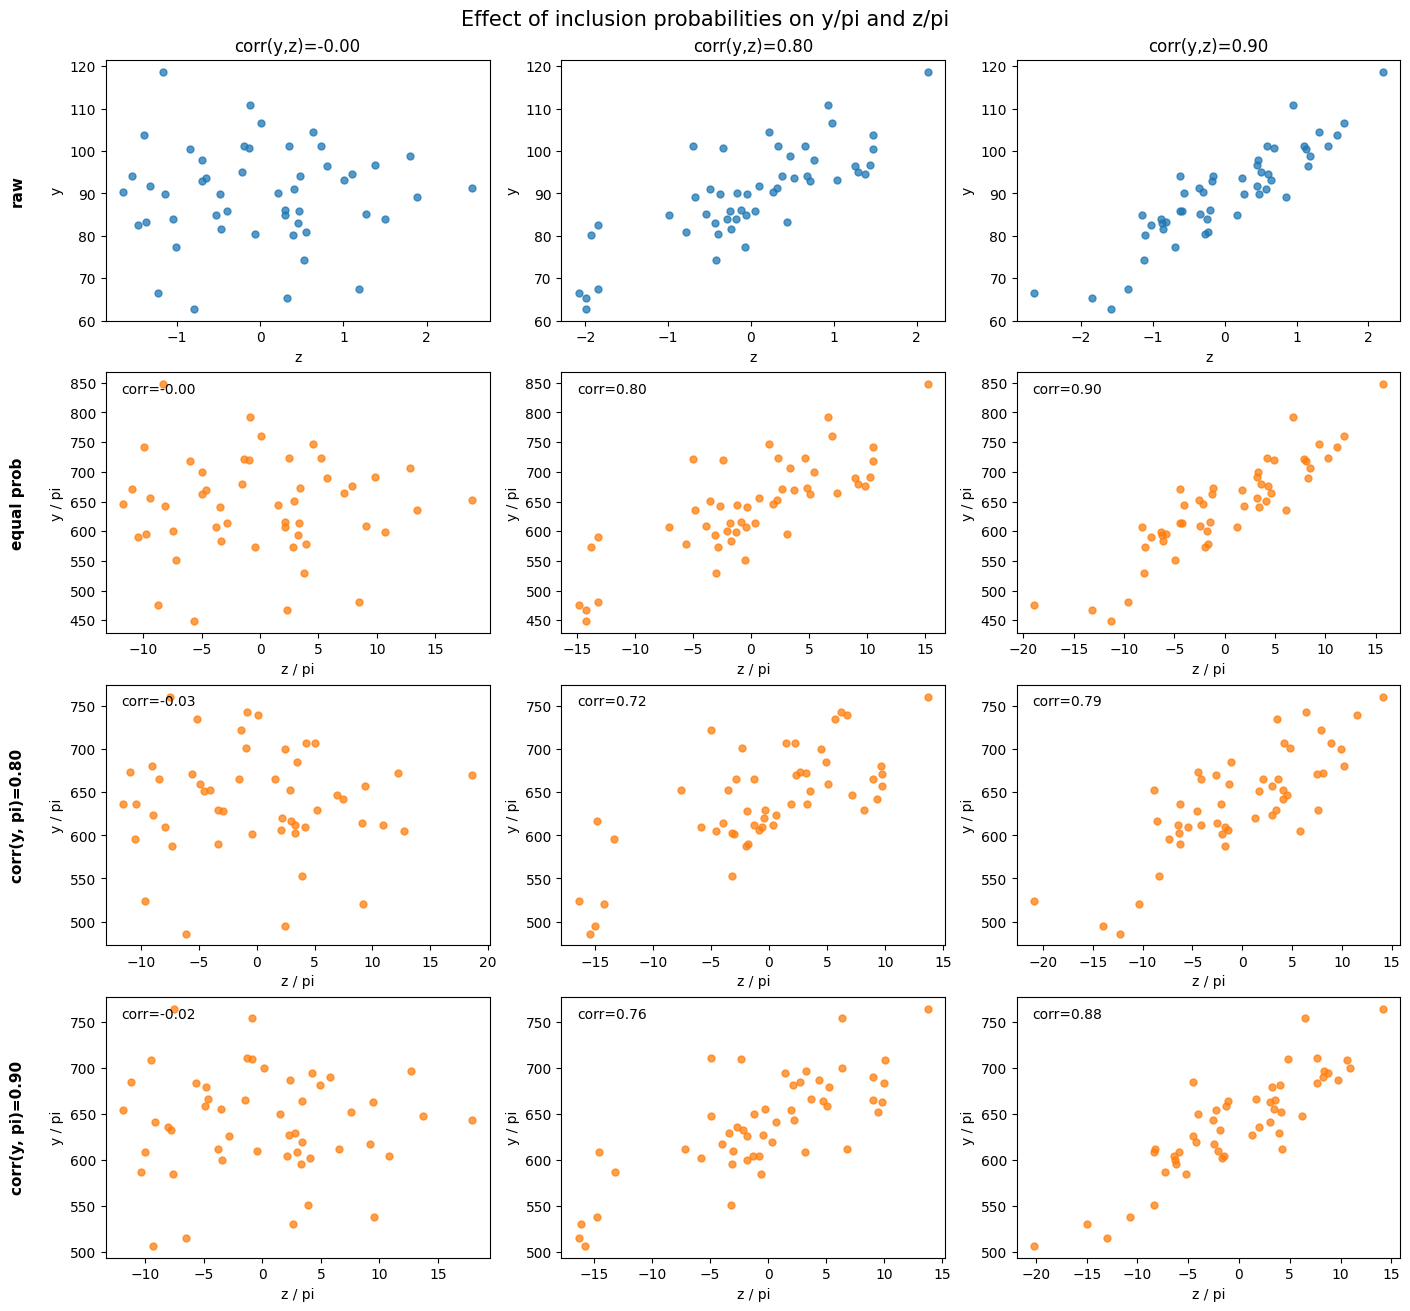

In [4]:
def plot_yz_and_scaled(df_pop, z_names, pi_dict):
    y = df_pop["y"].to_numpy(float)
    fig, axes = plt.subplots(4, 3, figsize=(14, 13), constrained_layout=True)
    row_names = ["raw", "equal prob", "corr(y, pi)=0.80", "corr(y, pi)=0.90"]
    pi_order = [None, "equal", "pi80", "pi90"]
    for col, z_name in enumerate(z_names):
        z = df_pop[z_name].to_numpy(float)
        r_raw = np.corrcoef(y, z)[0, 1]
        axes[0, col].scatter(z, y, s=25, alpha=0.75)
        axes[0, col].set_title(f"corr(y,z)={r_raw:.2f}")
        axes[0, col].set_xlabel("z")
        axes[0, col].set_ylabel("y")
        for row, pi_name in enumerate(pi_order[1:], start=1):
            pi = pi_dict[pi_name]
            r_scaled = np.corrcoef(y / pi, z / pi)[0, 1]
            axes[row, col].scatter(z / pi, y / pi, s=25, alpha=0.75, color="tab:orange")
            axes[row, col].text(0.04, 0.92, f"corr={r_scaled:.2f}", transform=axes[row, col].transAxes)
            axes[row, col].set_xlabel("z / pi")
            axes[row, col].set_ylabel("y / pi")
    for row, label in enumerate(row_names):
        axes[row, 0].annotate(label, xy=(-0.23, 0.5), xycoords="axes fraction", rotation=90,
                              va="center", ha="center", fontsize=11, fontweight="bold")
    fig.suptitle("Effect of inclusion probabilities on y/pi and z/pi", fontsize=15)
    plt.show()

plot_yz_and_scaled(df_pop, z_names, pi_dict)

## 5. Check the 9 Cases Before Running ABC

In [5]:
def vincent_check_for_case(y, z, pi):
    order = np.argsort(pi)[::-1]
    pi_s = pi[order]
    z_s = z[order]
    return {
        "pi_nonincreasing": bool(np.all(np.diff(pi_s) <= 1e-12)),
        "z_over_pi_increasing_after_pi_sort": bool(np.all(np.diff(z_s / pi_s) > 0)),
    }

rows = []
y = df_pop["y"].to_numpy(float)
for z_name in z_names:
    z = df_pop[z_name].to_numpy(float)
    for pi_name, pi in pi_dict.items():
        chk = vincent_check_for_case(y, z, pi)
        rows.append({
            "z_case": z_name,
            "pi_case": pi_name,
            "corr_y_z": np.corrcoef(y, z)[0, 1],
            "corr_y_pi": 0.0 if pi_name == "equal" else np.corrcoef(y, pi)[0, 1],
            "corr_y_over_pi_z_over_pi": np.corrcoef(y / pi, z / pi)[0, 1],
            **chk,
        })
case_check = pd.DataFrame(rows)
display(case_check.round(3))
print("Important: Vincent's theorem applies directly only when z/pi is monotone in the pi ordering.")

,z_case,pi_case,corr_y_z,corr_y_pi,corr_y_over_pi_z_over_pi,pi_nonincreasing,z_over_pi_increasing_after_pi_sort
0,z00,equal,-0.0,0.000,-0.000,True,False
1,z00,pi80,-0.0,0.799,-0.027,True,False
2,z00,pi90,-0.0,0.900,-0.020,True,False
3,z80,equal,0.8,0.000,0.800,True,False
4,z80,pi80,0.8,0.799,0.717,True,False
5,z80,pi90,0.8,0.900,0.764,True,False
6,z90,equal,0.9,0.000,0.900,True,False
7,z90,pi80,0.9,0.799,0.793,True,False
8,z90,pi90,0.9,0.900,0.882,True,False


Important: Vincent's theorem applies directly only when z/pi is monotone in the pi ordering.


## 6. ABC and Random Search Functions

In [6]:
@dataclass
class SearchState:
    omega: np.ndarray
    rho: np.ndarray
    eff_z: float
    eff_y: float
    score: float
    trial: int = 0


def case_references(y, z, pi):
    order_pi = np.argsort(pi)[::-1]
    y_s, z_s, pi_s = y[order_pi], z[order_pi], pi[order_pi]
    var_srs_y = srs_variance(y)
    var_srs_z = srs_variance(z)
    K_z = Ppi(pi_s) @ Ppi(pi_s).T
    vincent_eff_z = var_srs_z / ht_variance(K_z, pi_s, z_s)
    order_y = np.argsort(y / pi)
    K_y = Ppi(pi[order_y]) @ Ppi(pi[order_y]).T
    vincent_eff_y = var_srs_y / ht_variance(K_y, pi[order_y], y[order_y])
    return {"y_s": y_s, "z_s": z_s, "pi_s": pi_s, "var_srs_y": var_srs_y,
            "var_srs_z": var_srs_z, "vincent_eff_z": vincent_eff_z, "vincent_eff_y": vincent_eff_y}


def evaluate_design(y_s, z_s, pi_s, var_srs_y, var_srs_z, omega, rho, strict=True):
    try:
        K = CaDsd(pi=pi_s, M=N_SAMPLE, omega=omega, rho=rho)["K"]
    except Exception:
        return None
    if not kernel_is_valid(K, pi_s, strict=strict):
        return None
    var_y = ht_variance(K, pi_s, y_s)
    var_z = ht_variance(K, pi_s, z_s)
    if not np.isfinite(var_y) or not np.isfinite(var_z) or var_y <= 0 or var_z <= 0:
        return None
    eff_y = var_srs_y / var_y
    eff_z = var_srs_z / var_z
    if not np.isfinite(eff_y) or not np.isfinite(eff_z):
        return None
    return eff_z, eff_y


def random_arrays(rng):
    return rng.random((N_SAMPLE, N_UNITS)), rng.random((N_SAMPLE, N_UNITS - 1))


def run_one_case(y, z, pi, iterations=MAX_ITERATIONS, checkpoint_interval=CHECKPOINT_INTERVAL,
                 colony_size=COLONY_SIZE, seed=BASE_SEED, verbose=True):
    refs = case_references(y, z, pi)
    y_s, z_s, pi_s = refs["y_s"], refs["z_s"], refs["pi_s"]
    rng = np.random.default_rng(seed)
    strict = VALIDATION_MODE == "strict"

    def make_state(omega, rho):
        ev = evaluate_design(y_s, z_s, pi_s, refs["var_srs_y"], refs["var_srs_z"], omega, rho, strict=strict)
        if ev is None:
            return None
        eff_z, eff_y = ev
        return SearchState(omega.copy(), rho.copy(), eff_z, eff_y, eff_z)

    center_omega = np.zeros((N_SAMPLE, N_UNITS))
    center_rho = 0.5 * np.ones((N_SAMPLE, N_UNITS - 1))
    start_state = make_state(center_omega, center_rho)
    if start_state is None:
        raise RuntimeError("Vincent/CaDsd start was not valid")

    population = [start_state]
    attempts = 0
    while len(population) < colony_size and attempts < 200:
        omega, rho = random_arrays(rng)
        st = make_state(omega, rho)
        if st is not None:
            population.append(st)
        attempts += 1

    best = max(population, key=lambda s: s.score)
    random_best = start_state
    eval_abc = len(population)
    eval_random = eval_abc
    rows = []

    def record(iteration):
        rows.append({
            "iteration": iteration,
            "Start_z_over_V": start_state.eff_z / refs["vincent_eff_z"],
            "Start_y_over_Vy": start_state.eff_y / refs["vincent_eff_y"],
            "ABC_z_over_V": best.eff_z / refs["vincent_eff_z"],
            "ABC_y_over_Vy": best.eff_y / refs["vincent_eff_y"],
            "Random_z_over_V": random_best.eff_z / refs["vincent_eff_z"],
            "Random_y_over_Vy": random_best.eff_y / refs["vincent_eff_y"],
            "evaluations_ABC": eval_abc,
            "evaluations_Random": eval_random,
        })

    for it in range(1, iterations + 1):
        progress = it / max(1, iterations)
        before_eval = eval_abc
        new_population = []
        for state in population:
            partner = population[int(rng.integers(0, len(population)))]
            scale = max(0.12, 1.0 - 0.88 * progress)
            phi_o = rng.uniform(-scale, scale, state.omega.shape)
            phi_r = rng.uniform(-scale, scale, state.rho.shape)
            omega = state.omega + phi_o * (state.omega - partner.omega)
            rho = state.rho + phi_r * (state.rho - partner.rho)
            if progress > 0.10:
                pull = rng.uniform(0.0, 0.30 * progress)
                omega = omega + pull * (best.omega - omega)
                rho = rho + pull * (best.rho - rho)
            omega = np.clip(omega + rng.normal(0, 0.006 * scale, omega.shape), 0, 1)
            rho = np.clip(rho + rng.normal(0, 0.006 * scale, rho.shape), 0, 1)
            cand = make_state(omega, rho)
            eval_abc += 1
            if cand is not None and cand.score > state.score:
                new_population.append(cand)
                if cand.score > best.score:
                    best = cand
            else:
                state.trial += 1
                new_population.append(state)
        population = new_population

        for i, state in enumerate(population):
            if state.trial >= LIMIT:
                omega = np.clip(best.omega + rng.normal(0, 0.04, best.omega.shape), 0, 1)
                rho = np.clip(best.rho + rng.normal(0, 0.04, best.rho.shape), 0, 1)
                cand = make_state(omega, rho)
                eval_abc += 1
                if cand is not None:
                    population[i] = cand
                    if cand.score > best.score:
                        best = cand
                else:
                    state.trial = 0

        for _ in range(eval_abc - before_eval):
            omega, rho = random_arrays(rng)
            cand = make_state(omega, rho)
            eval_random += 1
            if cand is not None and cand.score > random_best.score:
                random_best = cand

        if it % checkpoint_interval == 0 or it == iterations:
            record(it)
            if verbose:
                last = rows[-1]
                print(f"iter={it:4d} ABC_z/V={last['ABC_z_over_V']:.3f} ABC_y/Vy={last['ABC_y_over_Vy']:.3f} "
                      f"Rnd_z/V={last['Random_z_over_V']:.3f} Rnd_y/Vy={last['Random_y_over_Vy']:.3f}")
    return pd.DataFrame(rows)

## 7. Run the 9 Cases

In [7]:
all_rows = []
y = df_pop["y"].to_numpy(float)

for z_name in z_names:
    z = df_pop[z_name].to_numpy(float)
    for pi_name, pi in pi_dict.items():
        print(f"Running {z_name} / {pi_name}")
        history = run_one_case(y, z, pi, iterations=MAX_ITERATIONS, checkpoint_interval=CHECKPOINT_INTERVAL,
                               seed=BASE_SEED + 100 * z_names.index(z_name) + list(pi_dict).index(pi_name))
        final = history.iloc[-1].to_dict()
        all_rows.append({
            "z_case": z_name,
            "pi_case": pi_name,
            "corr_y_z": np.corrcoef(y, z)[0, 1],
            "corr_y_pi": 0.0 if pi_name == "equal" else np.corrcoef(y, pi)[0, 1],
            "corr_y_over_pi_z_over_pi": np.corrcoef(y / pi, z / pi)[0, 1],
            **final,
        })

results = pd.DataFrame(all_rows)
display(results.round(3))

Running z00 / equal
iter= 100 ABC_z/V=1.301 ABC_y/Vy=0.105 Rnd_z/V=1.169 Rnd_y/Vy=0.100
Running z00 / pi80
iter= 100 ABC_z/V=1.234 ABC_y/Vy=0.145 Rnd_z/V=1.023 Rnd_y/Vy=0.120
Running z00 / pi90
iter= 100 ABC_z/V=1.182 ABC_y/Vy=0.153 Rnd_z/V=1.075 Rnd_y/Vy=0.144
Running z80 / equal
iter= 100 ABC_z/V=1.164 ABC_y/Vy=0.112 Rnd_z/V=1.054 Rnd_y/Vy=0.113
Running z80 / pi80
iter= 100 ABC_z/V=1.427 ABC_y/Vy=0.160 Rnd_z/V=1.000 Rnd_y/Vy=0.150
Running z80 / pi90
iter= 100 ABC_z/V=1.167 ABC_y/Vy=0.190 Rnd_z/V=1.000 Rnd_y/Vy=0.186
Running z90 / equal
iter= 100 ABC_z/V=1.110 ABC_y/Vy=0.123 Rnd_z/V=1.000 Rnd_y/Vy=0.109
Running z90 / pi80
iter= 100 ABC_z/V=1.175 ABC_y/Vy=0.168 Rnd_z/V=1.000 Rnd_y/Vy=0.150
Running z90 / pi90
iter= 100 ABC_z/V=1.152 ABC_y/Vy=0.201 Rnd_z/V=1.000 Rnd_y/Vy=0.186


,z_case,pi_case,corr_y_z,corr_y_pi,corr_y_over_pi_z_over_pi,iteration,Start_z_over_V,Start_y_over_Vy,ABC_z_over_V,ABC_y_over_Vy,Random_z_over_V,Random_y_over_Vy,evaluations_ABC,evaluations_Random
0,z00,equal,-0.0,0.000,-0.000,100.0,1.0,0.109,1.301,0.105,1.169,0.100,864.0,864.0
1,z00,pi80,-0.0,0.799,-0.027,100.0,1.0,0.150,1.234,0.145,1.023,0.120,837.0,837.0
2,z00,pi90,-0.0,0.900,-0.020,100.0,1.0,0.186,1.182,0.153,1.075,0.144,858.0,858.0
3,z80,equal,0.8,0.000,0.800,100.0,1.0,0.109,1.164,0.112,1.054,0.113,863.0,863.0
4,z80,pi80,0.8,0.799,0.717,100.0,1.0,0.150,1.427,0.160,1.000,0.150,837.0,837.0
5,z80,pi90,0.8,0.900,0.764,100.0,1.0,0.186,1.167,0.190,1.000,0.186,870.0,870.0
6,z90,equal,0.9,0.000,0.900,100.0,1.0,0.109,1.110,0.123,1.000,0.109,839.0,839.0
7,z90,pi80,0.9,0.799,0.793,100.0,1.0,0.150,1.175,0.168,1.000,0.150,841.0,841.0
8,z90,pi90,0.9,0.900,0.882,100.0,1.0,0.186,1.152,0.201,1.000,0.186,851.0,851.0


## 8. Compact Final Table

In [ ]:
compact_cols = [
    "z_case", "pi_case", "corr_y_z", "corr_y_pi", "corr_y_over_pi_z_over_pi",
    "Start_z_over_V", "Start_y_over_Vy", "ABC_z_over_V", "ABC_y_over_Vy",
    "Random_z_over_V", "Random_y_over_Vy",
]
compact = results[compact_cols].copy()
display(compact.round(2))

## 9. Notes for Interpretation

- `corr_y_z` is imposed by construction.
- `corr_y_pi` is imposed approximately through the inclusion probabilities.
- `corr_y_over_pi_z_over_pi` is the observed HT-scaled correlation.
- `Start z/V` should be close to 1 because we start from the Ppi/CaDsd reference.
- `Start y/Vy` is usually below 1 because the z-starting design is not necessarily y-optimal.
- `ABC z/V` and `ABC y/Vy` are computed using the best ABC design selected for z.
- Random search uses the same number of evaluations as ABC.
- If `z_over_pi_increasing_after_pi_sort` is false in the check table, Vincent's theorem should not be quoted as directly applying to that row.